<a href="https://colab.research.google.com/github/YakobHOR/ASSIGNMENT_14_Yakob/blob/main/ASSIGNMENT_14_Yakob_Komla_HOR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ASSIGNMENT_14_Yakob_Komla_HOR

In [4]:
# LIbraries:
!pip install fairlearn
!pip install lime
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from fairlearn.metrics import MetricFrame, selection_rate, false_positive_rate, true_positive_rate
import shap
import lime
import lime.lime_tabular
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
import joblib
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=548ed0ecb1d94c862da72f31ad5d35085b32a64ad07dfc493cc83a9c44f2c9eb
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [5]:
# Load the dataset (Adult income via OpenML)
from sklearn.datasets import fetch_openml

adult = fetch_openml("adult", version=2, as_frame=True)
df = adult.frame

# Target: income (>50K or <=50K)
y = (df["class"] == ">50K").astype(int)

# Sensitive attribute: sex
A = df["sex"]  # 'Male' / 'Female'

# Drop target and maybe some IDs
X = df.drop(columns=["class"])


In [6]:
# Basic preprocessing:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

preprocess = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

model = LogisticRegression(max_iter=1000)
clf = Pipeline(steps=[("preprocess", preprocess),
                     ("model", model)])


In [7]:
# Train/ test split and model evaluation:
X_train, X_test, y_train, y_test, A_train, A_test = train_test_split(
    X, y, A, test_size=0.3, random_state=42, stratify=y
)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification report:\n", classification_report(y_test, y_pred))


Accuracy: 0.8181259810277759
Confusion matrix:
 [[10619   528]
 [ 2137  1369]]
Classification report:
               precision    recall  f1-score   support

           0       0.83      0.95      0.89     11147
           1       0.72      0.39      0.51      3506

    accuracy                           0.82     14653
   macro avg       0.78      0.67      0.70     14653
weighted avg       0.81      0.82      0.80     14653



In [8]:
# Fairness analysis with Fairlearn:
# MetricFrame over sensitive groups:
metrics = {
    "selection_rate": selection_rate,
    "false_positive_rate": false_positive_rate,
    "true_positive_rate": true_positive_rate,
}

mf = MetricFrame(
    metrics=metrics,
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=A_test
)

print("Overall metrics:\n", mf.overall)
print("By sex:\n", mf.by_group)


Overall metrics:
 selection_rate         0.129462
false_positive_rate    0.047367
true_positive_rate     0.390473
dtype: float64
By sex:
         selection_rate  false_positive_rate  true_positive_rate
sex                                                            
Female        0.078443             0.039266            0.383363
Male          0.154757             0.052462            0.391805


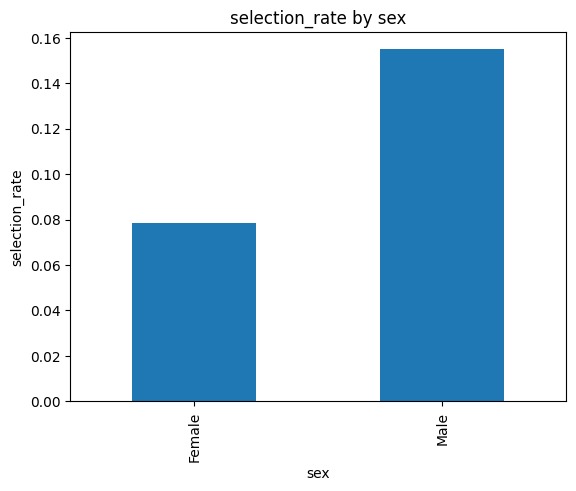

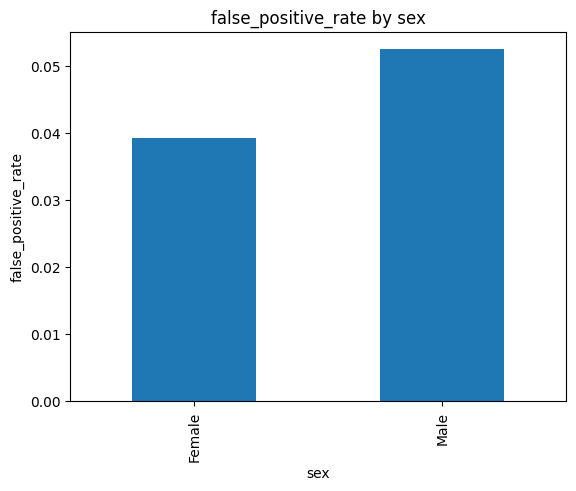

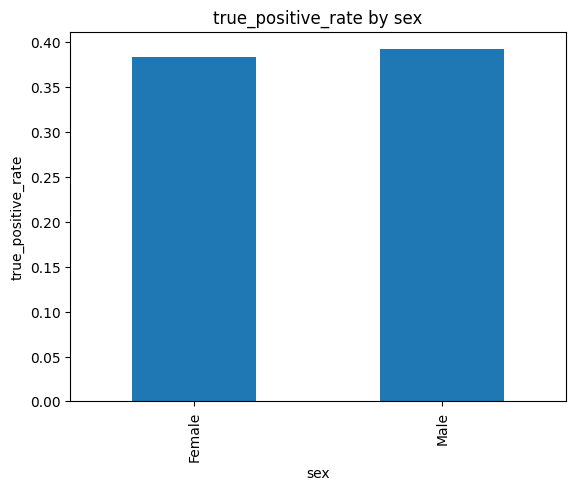

In [9]:
# Bar plot for interpretability:
for m in metrics.keys():
    mf.by_group[m].plot(kind="bar")
    plt.title(f"{m} by sex")
    plt.ylabel(m)
    plt.xlabel("sex")
    plt.show()


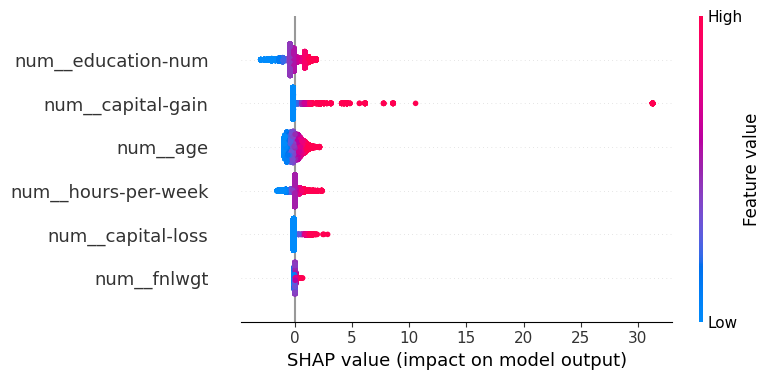

In [12]:
# Explainability with SHAP:
# fit SHAP explainer
# Get processed training data (needed for SHAP)
X_train_proc = clf.named_steps["preprocess"].transform(X_train)
X_test_proc  = clf.named_steps["preprocess"].transform(X_test)

# Extract feature names
feature_names = clf.named_steps["preprocess"].get_feature_names_out()

# SHAP Explainer
explainer = shap.Explainer(clf.named_steps["model"], X_train_proc)
shap_values = explainer(X_test_proc)

# Summary plot
shap.summary_plot(shap_values.values, X_test_proc, feature_names=feature_names)

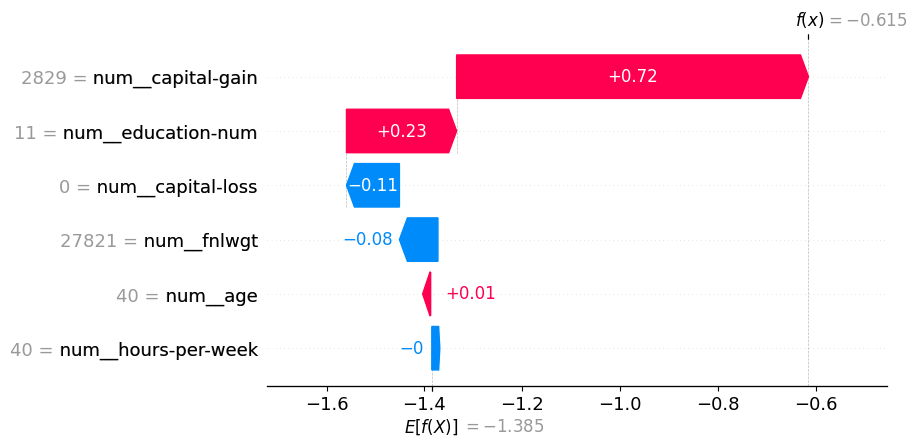

In [13]:
# Local explanation:
idx = 0  # choose any test sample
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[idx],
        base_values=explainer.expected_value,
        data=X_test_proc[idx],
        feature_names=feature_names
    )
)


In [16]:
# Explainability with LIME:
from lime.lime_tabular import LimeTabularExplainer

# Use encoded data from the fitted pipeline
X_train_proc = clf.named_steps["preprocess"].transform(X_train)
X_test_proc  = clf.named_steps["preprocess"].transform(X_test)

# Extract encoded feature names
feature_names = clf.named_steps["preprocess"].get_feature_names_out()

# Create LIME explainer using encoded numeric data
explainer_lime = LimeTabularExplainer(
    training_data=X_train_proc,
    feature_names=feature_names,
    class_names=["<=50K", ">50K"],
    discretize_continuous=True
)

# Prediction function for encoded data
def predict_proba_fn(x):
    return clf.named_steps["model"].predict_proba(x)

# Explain one encoded instance
i = 0
exp = explainer_lime.explain_instance(
    X_test_proc[i],
    predict_proba_fn,
    num_features=10
)

exp.show_in_notebook()

